In [ ]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================
# numpy: numerical computing and array operations
# torch: PyTorch deep learning framework
# matplotlib: plotting and visualization
# sklearn: machine learning utilities like train/test split

import numpy as np                          # numerical computations
import torch                                # PyTorch framework
import torch.nn as nn                       # neural network layers and modules
import torch.optim as optim                 # optimization algorithms (Adam, SGD, etc.)
import matplotlib.pyplot as plt             # plotting library

from torch.utils.data import DataLoader, TensorDataset  # batch data loading utilities

In [ ]:
# ============================================================
# PENDULUM PHYSICS: CONSTANTS AND FUNDAMENTAL EQUATIONS
# ============================================================
# Physical constants for a simple pendulum system

g = 9.81                    # gravitational acceleration (m/s^2)
L = 1.0                     # length of pendulum arm (m)
m = 1.0                     # mass of pendulum bob (kg)
dt = 0.05                   # time step for numerical integration (s)

def dynamics(theta, omega):
    """Compute derivatives of pendulum state using Newton's laws.

    This is the fundamental equation of motion for a simple pendulum:
    d²θ/dt² = -(g/L) * sin(θ)

    Input:
        theta: angular position (radians)
        omega: angular velocity (rad/s)
    Output:
        dtheta: rate of change of angle = angular velocity
        domega: rate of change of angular velocity (angular acceleration)
    """
    dtheta = omega                              # angle changes with angular velocity
    domega = -(g / L) * np.sin(theta)           # acceleration due to gravity
    return dtheta, domega

def energy(theta, omega):
    """Compute total mechanical energy of the pendulum.

    Total Energy = Kinetic Energy + Potential Energy
    E = 0.5*m*(L*omega)^2 + m*g*L*(1-cos(theta))

    In a frictionless system, energy is conserved (constant).
    This is our key metric for checking if models preserve physics.

    Returns:
        Total energy scalar value (Joules)
    """
    kinetic = 0.5 * m * (L * omega)**2          # rotational kinetic energy
    potential = m * g * L * (1 - np.cos(theta)) # gravitational potential energy
    return kinetic + potential

In [ ]:
def wrap_angle(theta):
    """Normalize angle to range [-π, π] radians.

    This prevents angles from growing unbounded and keeps them
    in the standard range for trigonometric functions.

    Example conversions:
        2π (360°) → 0
        3π → π
        -2π → 0
        1.5π → -0.5π

    Args:
        theta: angle in any range (radians)
    Returns:
        theta normalized to [-π, π]
    """
    return (theta + np.pi) % (2*np.pi) - np.pi

In [ ]:
def rk4_step(theta, omega, dt):
    """Advance pendulum state by one time step using 4th-order Runge-Kutta (RK4).

    RK4 is a high-accuracy numerical integration method that evaluates
    the derivative at 4 carefully chosen points to provide high accuracy.

    It's the "ground truth" integrator - we trust RK4 to give us
    the correct pendulum dynamics for training the neural networks.

    Args:
        theta: current angular position (radians)
        omega: current angular velocity (rad/s)
        dt: time step size (seconds)
    Returns:
        theta_next: updated angle at time t+dt
        omega_next: updated angular velocity at time t+dt
    """
    # ---- RK4 Stage 1: Evaluate derivative at current point (t) ----
    k1_th, k1_om = dynamics(theta, omega)

    # ---- RK4 Stage 2: Evaluate derivative at midpoint using k1 ----
    k2_th, k2_om = dynamics(theta + 0.5*dt*k1_th, omega + 0.5*dt*k1_om)

    # ---- RK4 Stage 3: Evaluate derivative at midpoint using k2 ----
    k3_th, k3_om = dynamics(theta + 0.5*dt*k2_th, omega + 0.5*dt*k2_om)

    # ---- RK4 Stage 4: Evaluate derivative at endpoint using k3 ----
    k4_th, k4_om = dynamics(theta + dt*k3_th, omega + dt*k3_om)

    # ---- Combine slopes with weights: RK4 formula is (1/6)(k1 + 2k2 + 2k3 + k4) ----
    # Midpoint estimates (k2, k3) are weighted 2x more than endpoints (k1, k4)
    theta_next = theta + (dt/6)*(k1_th + 2*k2_th + 2*k3_th + k4_th)
    theta_next = wrap_angle(theta_next)                                      # keep angle in valid range
    omega_next = omega + (dt/6)*(k1_om + 2*k2_om + 2*k3_om + k4_om)

    return theta_next, omega_next

In [ ]:
def generate_dataset(n_trajectories=200, steps=100):
    """Generate training dataset of pendulum trajectories for the standard NN.

    This function generates state transition pairs (state_t → state_t+1)
    where both the input and output are full state vectors.

    The standard NN learns: given [θ, ω] at time t, predict [θ, ω] at time t+dt
    This is like learning a discrete integrator without any physical constraints.

    Args:
        n_trajectories: number of random initial conditions to sample (default 200)
        steps: number of integration steps per trajectory (default 100)
    Returns:
        X: array of shape (n_samples, 2) containing states [θ, ω]
        Y: array of shape (n_samples, 2) containing next states [θ_next, ω_next]
    """
    X, Y = [], []

    # Generate trajectories starting from random initial conditions
    for traj_idx in range(n_trajectories):
        # Random initial state within reasonable bounds
        theta = np.random.uniform(-np.pi, np.pi)        # angle: -180° to +180°
        omega = np.random.uniform(-2, 2)                # angular velocity: -2 to +2 rad/s

        # Integrate forward for specified number of steps
        for step_idx in range(steps):
            # Integrate one step forward using ground truth RK4
            theta_next, omega_next = rk4_step(theta, omega, dt)
            print(f"Generated trajectory {traj_idx+1}/{n_trajectories}, step {step_idx+1}/{steps}: θ={theta:.3f}, ω={omega:.3f}")

            # Store state transition pair
            X.append([theta, omega])                     # current state
            Y.append([theta_next, omega_next])           # next state (ground truth)

            # Move forward in trajectory
            theta, omega = theta_next, omega_next

    return np.array(X), np.array(Y)

# Generate and display dataset shapes
X, Y = generate_dataset()
print(f"\nDataset generated!")
print(f"X shape: {X.shape}  (number of samples, state dimension)")
print(f"Y shape: {Y.shape}  (number of samples, state dimension)")

Streaming output truncated to the last 5000 lines.
Generated trajectory 151/200, step 5/100: θ=-0.365, ω=1.076
Generated trajectory 151/200, step 6/100: θ=-0.307, ω=1.238
Generated trajectory 151/200, step 7/100: θ=-0.242, ω=1.371
Generated trajectory 151/200, step 8/100: θ=-0.171, ω=1.472
Generated trajectory 151/200, step 9/100: θ=-0.095, ω=1.537
Generated trajectory 151/200, step 10/100: θ=-0.018, ω=1.565
Generated trajectory 151/200, step 11/100: θ=0.060, ω=1.554
Generated trajectory 151/200, step 12/100: θ=0.137, ω=1.506
Generated trajectory 151/200, step 13/100: θ=0.210, ω=1.421
Generated trajectory 151/200, step 14/100: θ=0.279, ω=1.302
Generated trajectory 151/200, step 15/100: θ=0.340, ω=1.152
Generated trajectory 151/200, step 16/100: θ=0.393, ω=0.976
Generated trajectory 151/200, step 17/100: θ=0.437, ω=0.778
Generated trajectory 151/200, step 18/100: θ=0.471, ω=0.562
Generated trajectory 151/200, step 19/100: θ=0.493, ω=0.334
Generated trajectory 151/200, step 20/100: θ=0.5

In [ ]:
# ============================================================
# PREPARE DATA FOR STANDARD NEURAL NETWORK
# ============================================================
# Split data into training and test sets

from sklearn.model_selection import train_test_split

# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

# Convert numpy arrays to PyTorch tensors with float32 precision
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create a DataLoader for batch training (processes 64 samples at a time)
# Shuffling helps prevent the model from overfitting to data order
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,           # number of samples per batch
    shuffle=True             # randomize order each epoch
)

In [ ]:
X_test.shape

torch.Size([4000, 2])

In [ ]:
# ============================================================
# STANDARD NEURAL NETWORK (NN) - No Physics Constraints
# ============================================================
# This network learns pure data-fitting WITHOUT knowledge of physics.
# It tries to fit [θ, ω] → [θ_next, ω_next] as a black box.

class NN(nn.Module):
    """Standard feedforward neural network for state prediction.

    Architecture:
        Input (2 dims) → Dense(64) → Tanh → Dense(64) → Tanh → Output (2 dims)

    This network has NO inductive bias toward physics.
    It will likely fail to conserve energy over long rollouts.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),        # Input layer: 2 → 64 neurons
            nn.Tanh(),               # Activation: bounded [-1, 1], smooth
            nn.Linear(64, 64),       # Hidden layer: 64 → 64 neurons
            nn.Tanh(),               # Activation: bounded [-1, 1], smooth
            nn.Linear(64, 2)         # Output layer: 64 → 2 neurons (θ_next, ω_next)
        )

    def forward(self, x):
        """Forward pass: predict next state [θ_next, ω_next] given current state."""
        return self.net(x)

# Instantiate model, optimizer, and loss function
model = NN()                                    # create the network
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam optimizer with learning rate 0.001
loss_fn = nn.MSELoss()                         # Mean Squared Error loss

In [ ]:
# ============================================================
# TRAIN STANDARD NEURAL NETWORK
# ============================================================
# Standard supervised learning: minimize prediction error on state transitions

loss_history = []
EPOCHS = 200  # number of complete passes through the training data

print("Training Standard NN (No Physics Constraints)...")
for epoch in range(EPOCHS):
    total_loss = 0

    # Process each batch of training data
    for xb, yb in train_loader:
        # Forward pass: predict next state
        pred = model(xb)                    # predict [θ_next, ω_next]

        # Compute loss between prediction and ground truth
        loss = loss_fn(pred, yb)            # MSE between pred and true next states

        # Backward pass: compute gradients
        optimizer.zero_grad()               # clear old gradients
        loss.backward()                     # backpropagation: compute ∂loss/∂weights
        optimizer.step()                    # update weights: w = w - lr * ∇loss

        # Accumulate loss for this batch
        total_loss += loss.item() * xb.size(0)

    # Average loss over all training samples
    total_loss /= len(train_loader.dataset)
    loss_history.append(total_loss)

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {total_loss:.6f}")

print("NN training complete!\n")

Training Standard NN (No Physics Constraints)...
Epoch 20/200, Loss: 0.045589
Epoch 40/200, Loss: 0.042660
Epoch 60/200, Loss: 0.037410
Epoch 80/200, Loss: 0.032938
Epoch 100/200, Loss: 0.029359
Epoch 120/200, Loss: 0.027854
Epoch 140/200, Loss: 0.025328
Epoch 160/200, Loss: 0.027039
Epoch 180/200, Loss: 0.024837
Epoch 200/200, Loss: 0.021656
NN training complete!



In [ ]:
def rollout(model, theta0, omega0, steps=200):
    """Generate long trajectory by repeatedly applying the learned model.

    Start from initial state and iteratively predict next state.
    This tests if the model can maintain stability over many steps.

    Note: errors accumulate! Small one-step errors compound into
    large trajectory deviations over time.

    Args:
        model: trained neural network (NN or HNN)
        theta0: initial angle
        omega0: initial angular velocity
        steps: number of forward prediction steps (default 200)
    Returns:
        traj: array of shape (steps, 2) with predicted trajectory
    """
    theta, omega = theta0, omega0
    traj = []

    # Predict forward step by step
    for step_idx in range(steps):
        # Prepare input as batch of 1 sample
        inp = torch.tensor([[theta, omega]], dtype=torch.float32)

        # Get prediction from model (no gradient tracking)
        pred = model(inp).detach().numpy()[0]  # convert to numpy [θ_next, ω_next]

        # Extract predicted state
        theta, omega = pred
        theta = wrap_angle(theta)              # normalize angle to [-π, π]

        # Store in trajectory
        traj.append([theta, omega])

    return np.array(traj)

In [ ]:
with torch.no_grad():
    pred_test = model(X_test)
    test_loss = loss_fn(pred_test, y_test)

print("Test MSE Loss:", test_loss.item())

Test MSE Loss: 0.023102600127458572


In [ ]:
with torch.no_grad():
    pred = model(X_test)

theta_error = torch.mean((pred[:,0] - y_test[:,0])**2)
omega_error = torch.mean((pred[:,1] - y_test[:,1])**2)

print("Theta MSE:", theta_error.item())
print("Omega MSE:", omega_error.item())

Theta MSE: 0.04529105871915817
Omega MSE: 0.0009141471236944199


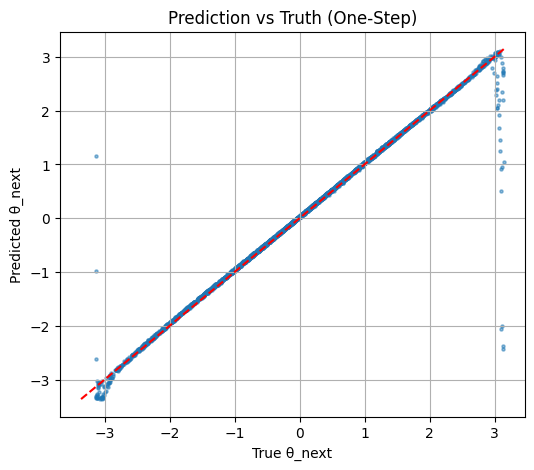

In [ ]:
import numpy as np

# Convert tensors to numpy for plotting
with torch.no_grad():
    pred_test = model(X_test).numpy()
true_test = y_test.numpy()

plt.figure(figsize=(6,5))
plt.scatter(true_test[:,0], pred_test[:,0], s=5, alpha=0.5)

min_val = min(true_test[:,0].min(), pred_test[:,0].min())
max_val = max(true_test[:,0].max(), pred_test[:,0].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # ideal line

plt.xlabel("True θ_next")
plt.ylabel("Predicted θ_next")
plt.title("Prediction vs Truth (One-Step)")
plt.grid()
plt.show()

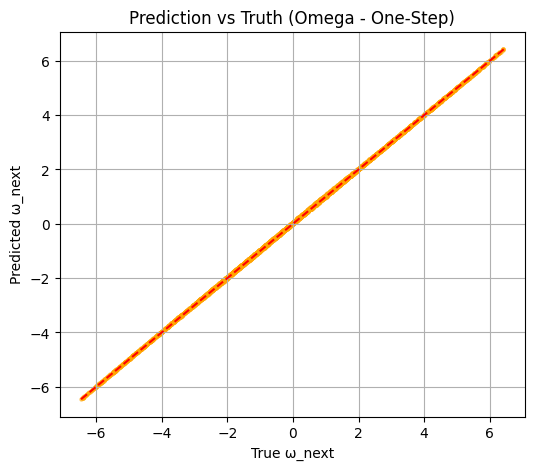

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(true_test[:,1], pred_test[:,1], s=5, alpha=0.5, color='orange')

min_val = min(true_test[:,1].min(), pred_test[:,1].min())
max_val = max(true_test[:,1].max(), pred_test[:,1].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # ideal line

plt.xlabel('True ω_next')
plt.ylabel('Predicted ω_next')
plt.title('Prediction vs Truth (Omega - One-Step)')
plt.grid()
plt.show()

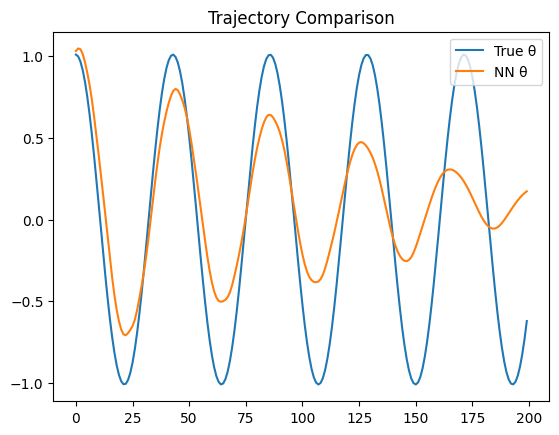

In [ ]:
theta0 = 1.0
omega0 = 0.4

true_traj = []
theta, omega = theta0, omega0

for _ in range(200):
    theta, omega = rk4_step(theta, omega, dt)
    true_traj.append([theta, omega])

true_traj = np.array(true_traj)
nn_traj = rollout(model, theta0, omega0)

plt.plot(true_traj[:,0], label="True θ")
plt.plot(nn_traj[:,0], label="NN θ")
plt.legend()
plt.title("Trajectory Comparison")
plt.show()

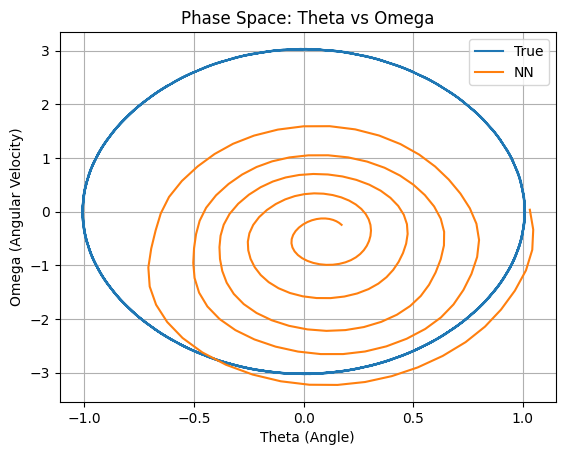

In [ ]:
plt.plot(true_traj[:,0], true_traj[:,1], label="True")
plt.plot(nn_traj[:,0], nn_traj[:,1], label="NN")
plt.xlabel("Theta (Angle)")
plt.ylabel("Omega (Angular Velocity)")
plt.title("Phase Space: Theta vs Omega")
plt.legend()
plt.grid()
plt.show()

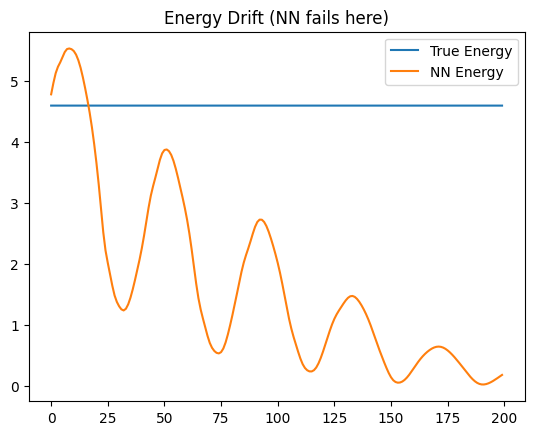

In [ ]:
true_E = energy(true_traj[:,0], true_traj[:,1])
nn_E = energy(nn_traj[:,0], nn_traj[:,1])

plt.plot(true_E, label="True Energy")
plt.plot(nn_E, label="NN Energy")
plt.legend()
plt.title("Energy Drift (NN fails here)")
plt.show()

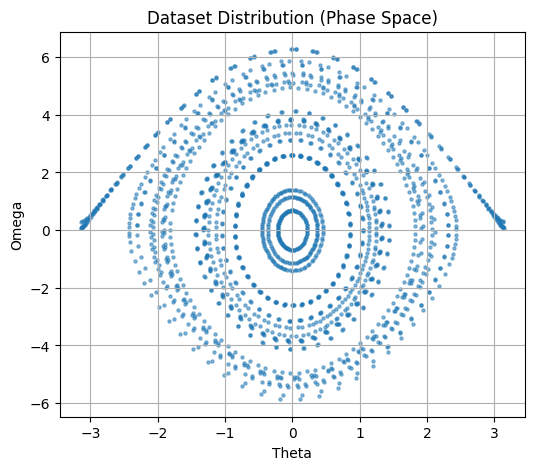

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:2000,0], X[:2000,1], s=5, alpha=0.5)
plt.xlabel("Theta")
plt.ylabel("Omega")
plt.title("Dataset Distribution (Phase Space)")
plt.grid()
plt.show()

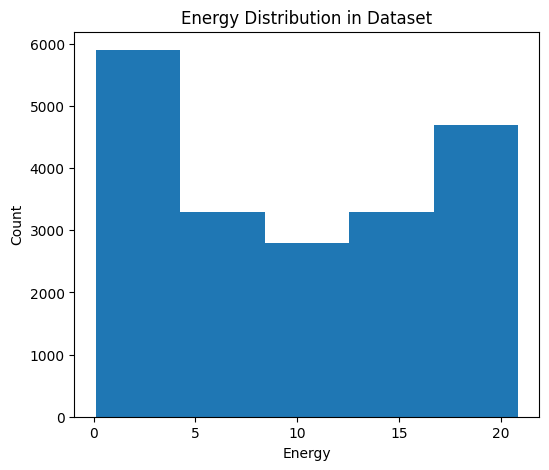

In [ ]:
plt.figure(figsize=(6,5))
E_data = energy(X[:,0], X[:,1])

plt.hist(E_data, bins=5)
plt.title("Energy Distribution in Dataset")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

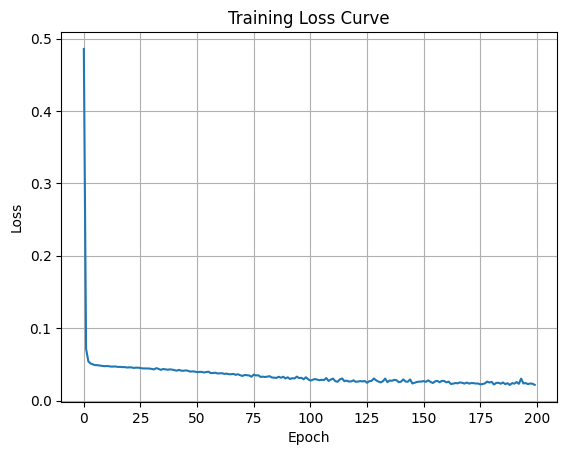

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

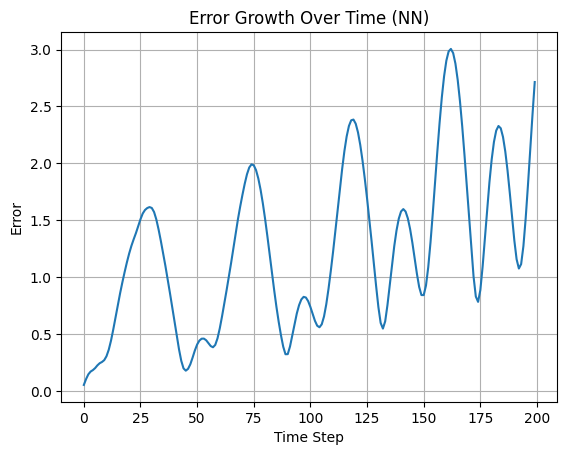

In [ ]:
def compute_error(true_traj, pred_traj):
    return np.linalg.norm(true_traj - pred_traj, axis=1)

error = compute_error(true_traj, nn_traj)

plt.plot(error)
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.title("Error Growth Over Time (NN)")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# HAMILTONIAN NEURAL NETWORK (HNN) - WITH PHYSICS CONSTRAINTS
# ============================================================
# For HNN training, we need a different dataset:
# Instead of (state → next_state), we need (state → derivative)
# HNN will learn: given [\u03b8, ω], predict [dθ/dt, dω/dt]

def generate_derivative_dataset(n_trajectories=200, steps=100):
    """Generate training dataset for Hamiltonian Neural Network (HNN).

    Unlike the standard NN which predicts full next state,
    HNN predicts the time derivatives (dynamics) at a state.

    This allows HNN to be integrated forward using any integrator
    and automatically conserves energy through Hamiltonian structure.

    Args:
        n_trajectories: number of random initial conditions
        steps: integration steps per trajectory
    Returns:
        X: array of shape (n_samples, 2) containing states [\u03b8, ω]
        dX: array of shape (n_samples, 2) containing derivatives [dθ/dt, dω/dt]
    """
    X, dX = [], []

    # Generate trajectories from random initial conditions
    for traj_idx in range(n_trajectories):
        theta = np.random.uniform(-np.pi, np.pi)
        omega = np.random.uniform(-2, 2)

        for step_idx in range(steps):
            # Compute true derivatives at this state
            dtheta, domega = dynamics(theta, omega)

            # Store state and its derivatives
            X.append([theta, omega])              # current state
            dX.append([dtheta, domega])           # time derivatives at this state

            # Move to next state for next iteration
            theta, omega = rk4_step(theta, omega, dt)

    return np.array(X), np.array(dX)

# Generate HNN training dataset
print("Generating Hamiltonian Neural Network dataset...")
X_hnn, dX_hnn = generate_derivative_dataset()
print(f"HNN dataset shapes: X={X_hnn.shape}, dX={dX_hnn.shape}")

Generating Hamiltonian Neural Network dataset...
HNN dataset shapes: X=(20000, 2), dX=(20000, 2)


In [ ]:
# ============================================================
# PREPARE DATA FOR HAMILTONIAN NEURAL NETWORK (HNN)
# ============================================================
# For HNN, we train on state→derivatives instead of state→next_state
# This allows the HNN to learn the Hamiltonian structure

from sklearn.model_selection import train_test_split

# Split HNN derivative dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_hnn, dX_hnn, test_size=0.2, random_state=42, shuffle=True
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader for HNN training with batch processing
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

print(f"HNN training data prepared!")
print(f"  X_train shape: {X_train.shape}  (states to train on)")
print(f"  y_train shape: {y_train.shape}  (derivatives to learn)")

HNN training data prepared!
  X_train shape: torch.Size([16000, 2])  (states to train on)
  y_train shape: torch.Size([16000, 2])  (derivatives to learn)


In [ ]:
# ============================================================
# HAMILTONIAN NEURAL NETWORK (HNN) CLASS
# ============================================================
# Key insight: Use automatic differentiation to enforce physics!
#
# Instead of learning dynamics directly, learn a Hamiltonian H(θ, ω).
# Then use calculus to get dynamics: [dθ/dt, dω/dt] = [∂H/∂ω, -∂H/∂θ]
#
# Benefit: This structure automatically conserves energy!

class HNN(nn.Module):
    """Hamiltonian Neural Network for physics-aware learning.

    The HNN learns a scalar Hamiltonian (energy) function H(state).
    The actual dynamics emerge from gradients via the canonical equations:
        dθ/dt = ∂H/∂ω        (position derivative = momentum derivative)
        dω/dt = -∂H/∂θ       (momentum derivative = -position derivative)

    This structure automatically guarantees energy conservation!
    """
    def __init__(self):
        super().__init__()
        # Network that outputs a scalar Hamiltonian value
        self.net = nn.Sequential(
            nn.Linear(2, 64),       # Input: [θ, ω]
            nn.Tanh(),              # Nonlinearity
            nn.Linear(64, 64),      # Hidden: 64 neurons
            nn.Tanh(),              # Nonlinearity
            nn.Linear(64, 1)        # Output: scalar H (total energy)
        )

    def forward(self, x):
        """Forward pass: convert Hamiltonian to dynamics using auto-differentiation.

        Args:
            x: state tensor of shape (batch_size, 2) with [θ, ω]
        Returns:
            dynamics: tensor of shape (batch_size, 2) with [dθ/dt, dω/dt]
        """
        # Enable gradient computation for the state variable
        x.requires_grad_(True)

        # Compute Hamiltonian (total energy) for each sample in batch
        H = self.net(x)

        # Use PyTorch autograd to compute ∂H/∂x = [∂H/∂θ, ∂H/∂ω]
        # create_graph=True allows higher-order derivatives if needed
        dH = torch.autograd.grad(
            H.sum(), x, create_graph=True
        )[0]  # shape: (batch_size, 2)

        # Apply canonical Hamiltonian equations:
        # dθ/dt = ∂H/∂ω (position changes with momentum derivative)
        # dω/dt = -∂H/∂θ (momentum changes with -position derivative)
        dtheta = dH[:, 1]           # ∂H/∂ω
        domega = -dH[:, 0]          # -∂H/∂θ

        # Stack dynamics back into batch tensor
        return torch.stack([dtheta, domega], dim=1)

In [ ]:
# ============================================================
# TRAIN HAMILTONIAN NEURAL NETWORK
# ============================================================
# HNN learns to predict derivatives [dθ/dt, dω/dt] instead of next states.
# The Hamiltonian structure automatically enforces energy conservation!

hnn = HNN()                                    # create HNN model
optimizer = optim.Adam(hnn.parameters(), lr=1e-3)  # Adam optimizer
loss_fn = nn.MSELoss()                         # Mean squared error loss

EPOCHS = 200
loss_history_hnn = []

print("Training Hamiltonian Neural Network (Physics-Aware)...")
for epoch in range(EPOCHS):
    total_loss = 0

    # Process each batch of training data
    for xb, yb in train_loader:
        # Forward pass: predict derivatives [dθ/dt, dω/dt]
        pred = hnn(xb)                      # HNN predicts time derivatives

        # Compute loss: how well do predicted derivatives match true derivatives?
        loss = loss_fn(pred, yb)            # MSE between predicted and true derivatives

        # Backward pass: compute gradients
        optimizer.zero_grad()               # clear old gradients
        loss.backward()                     # backpropagation
        optimizer.step()                    # update weights

        # Accumulate loss
        total_loss += loss.item() * xb.size(0)

    # Average loss over training data
    total_loss /= len(train_loader.dataset)
    loss_history_hnn.append(total_loss)

    # Print progress
    if epoch % 20 == 0:
        print(f"HNN Epoch {epoch}/{EPOCHS}, Loss: {total_loss:.6f}")

print("HNN training complete!\n")

Training Hamiltonian Neural Network (Physics-Aware)...
HNN Epoch 0/200, Loss: 10.192827
HNN Epoch 20/200, Loss: 0.002804
HNN Epoch 40/200, Loss: 0.000647
HNN Epoch 60/200, Loss: 0.000588
HNN Epoch 80/200, Loss: 0.001014
HNN Epoch 100/200, Loss: 0.000660
HNN Epoch 120/200, Loss: 0.001006
HNN Epoch 140/200, Loss: 0.000113
HNN Epoch 160/200, Loss: 0.000209
HNN Epoch 180/200, Loss: 0.000205
HNN training complete!



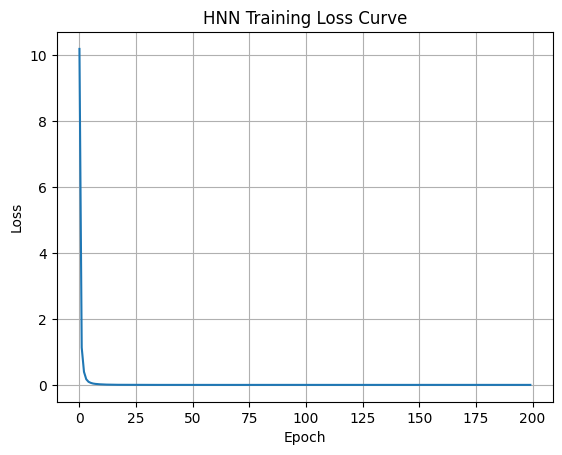

In [ ]:
plt.plot(loss_history_hnn)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("HNN Training Loss Curve")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# HNN ROLLOUT FUNCTIONS
# ============================================================
# To use HNN for prediction, we need to integrate its learned dynamics forward.
# We use RK4 integration (just like the ground truth) for consistency.

def hnn_dynamics(x):
    """Get time derivatives from trained HNN.

    Converts numpy array to tensor, gets HNN predictions, converts back.

    Args:
        x: state as numpy array [θ, ω]
    Returns:
        dynamics as numpy array [dθ/dt, dω/dt]
    """
    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # convert to tensor batch
    return hnn(x_t).detach().numpy()[0]  # extract first sample, convert to numpy

def rk4_hnn(theta, omega):
    """Advance HNN state by one time step using RK4 integration.

    Same as rk4_step() but using HNN's learned dynamics instead of true dynamics.
    This tests if HNN has learned the correct equations of motion.

    Args:
        theta: current angle
        omega: current angular velocity
    Returns:
        theta_next: updated angle
        omega_next: updated angular velocity
    """
    # Nested function to organize RK4 stages
    def f(th, om):
        return hnn_dynamics([th, om])

    # Compute 4 evaluation stages
    k1 = f(theta, omega)
    k2 = f(theta + 0.5*dt*k1[0], omega + 0.5*dt*k1[1])
    k3 = f(theta + 0.5*dt*k2[0], omega + 0.5*dt*k2[1])
    k4 = f(theta + dt*k3[0], omega + dt*k3[1])

    # RK4 weighted average of slopes
    theta_next = theta + (dt/6)*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    omega_next = omega + (dt/6)*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])

    theta_next = wrap_angle(theta_next)

    return theta_next, omega_next

In [ ]:
def rollout_hnn(theta0, omega0, steps=200):
    """Generate trajectory using HNN's learned dynamics with RK4 integration.

    This tests:
    1. Did HNN learn the correct dynamics?
    2. Does the Hamiltonian structure conserve energy?
    3. How stable is the trajectory over long rollouts?

    Args:
        theta0: initial angle
        omega0: initial angular velocity
        steps: number of RK4 integration steps
    Returns:
        traj: array of shape (steps, 2) with HNN rollout trajectory
    """
    theta, omega = theta0, omega0
    traj = []

    # Integrate forward using HNN dynamics
    for _ in range(steps):
        theta, omega = rk4_hnn(theta, omega)  # RK4 step using HNN dynamics
        traj.append([theta, omega])

    return np.array(traj)

Generating trajectories...


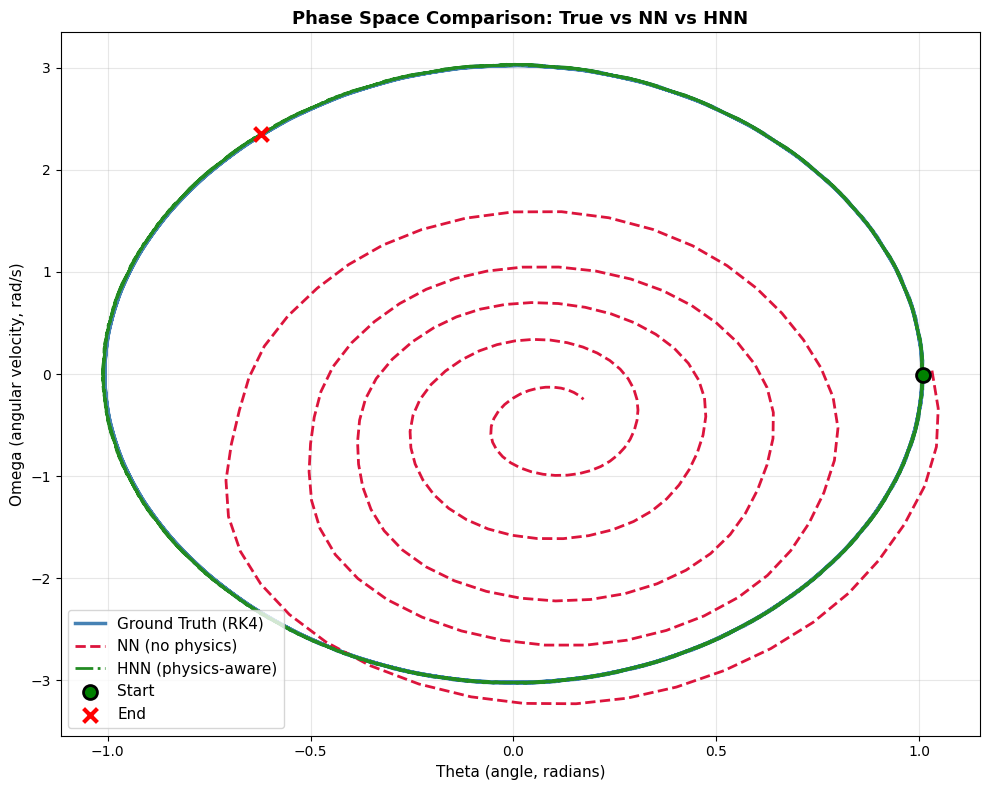

In [ ]:
# ============================================================
# GENERATE TRAJECTORIES FOR COMPARISON
# ============================================================
# Compare three models:
# 1. Ground Truth (RK4 integrator) - the reference
# 2. Standard NN - black-box learned dynamics (no physics)
# 3. HNN - physics-aware learned dynamics (energy conserving)

# Starting conditions for the rollout test
theta0 = 1.0                                   # initial angle (radians)
omega0 = 0.4                                   # initial angular velocity

# ---- Generate Ground Truth Trajectory ----
# This is our reference - use the true pendulum equations with RK4
print("Generating trajectories...")
theta, omega = theta0, omega0
true_traj = []
for _ in range(200):
    theta, omega = rk4_step(theta, omega, dt)  # integrate true dynamics
    true_traj.append([theta, omega])
true_traj = np.array(true_traj)

# ---- Generate NN Trajectory ----
# Standard NN predicts next state (may drift due to no physics constraint)
nn_traj = rollout(model, theta0, omega0)

# ---- Generate HNN Trajectory ----
# HNN predicts derivatives, integrated with RK4 (should conserve energy)
hnn_traj = rollout_hnn(theta0, omega0)

# ---- Visualize Phase Space Trajectories ----
# Phase space is a 2D plot of position vs momentum (θ vs ω)
# Closed loops in phase space indicate energy conservation
# Spiraling outward/inward indicates energy drift

plt.figure(figsize=(10, 8))
plt.plot(true_traj[:,0], true_traj[:,1], linewidth=2.5, color='steelblue', label='Ground Truth (RK4)')
plt.plot(nn_traj[:,0], nn_traj[:,1], '--', linewidth=2, color='crimson', label='NN (no physics)')
plt.plot(hnn_traj[:,0], hnn_traj[:,1], '-.', linewidth=2, color='forestgreen', label='HNN (physics-aware)')

# Mark start and end points
plt.scatter(true_traj[0, 0], true_traj[0, 1], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start', zorder=5)
plt.scatter(true_traj[-1, 0], true_traj[-1, 1], color='red', s=100, marker='x', linewidths=3, label='End', zorder=5)

plt.legend(fontsize=11)
plt.title("Phase Space Comparison: True vs NN vs HNN", fontsize=13, fontweight='bold')
plt.xlabel("Theta (angle, radians)", fontsize=11)
plt.ylabel("Omega (angular velocity, rad/s)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

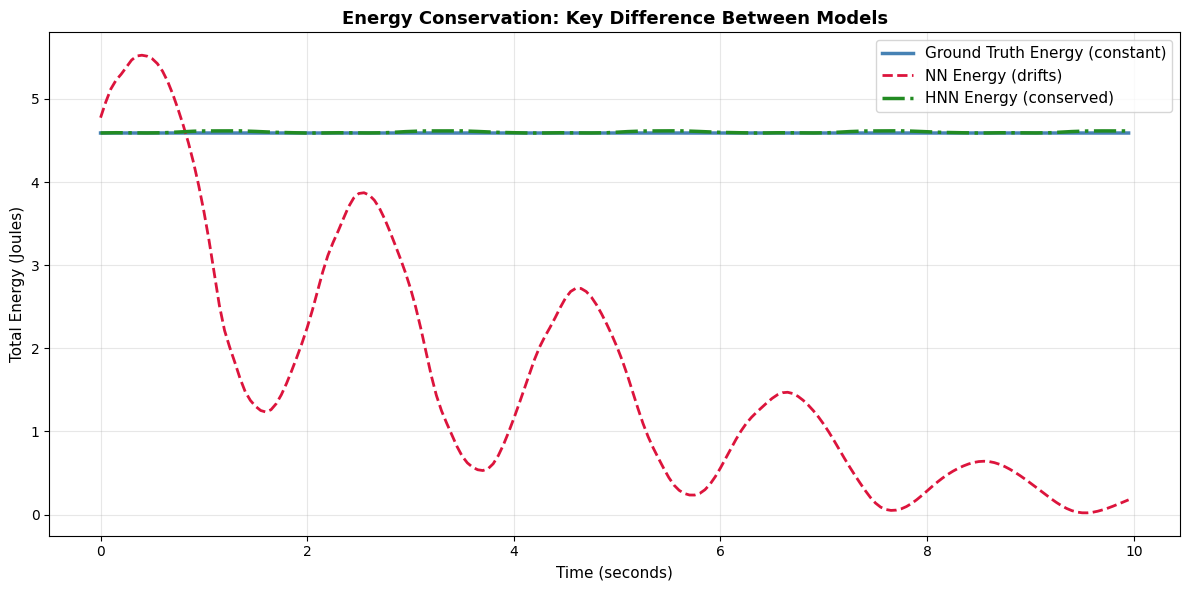


ENERGY CONSERVATION ANALYSIS

True Trajectory Energy:
  Mean:   4.589566 J
  Std:    3.891123e-05 J (essentially zero - perfectly conserved)
  Max:    4.589635 J
  Min:    4.589498 J

NN Trajectory Energy (NO physics constraint):
  Mean:   1.666853 J
  Std:    1.530007 J (large - energy drifts!)
  Max:    5.525581 J
  Min:    0.020133 J

HNN Trajectory Energy (physics constraint):
  Mean:   4.600821 J
  Std:    0.009882 J (small - nearly conserved!)
  Max:    4.616070 J
  Min:    4.589211 J


In [ ]:
# ============================================================
# ENERGY CONSERVATION COMPARISON
# ============================================================
# The key difference between models:
# - Ground truth: energy stays constant (closed loop in energy plot)
# - NN: energy drifts (no physics constraint)
# - HNN: energy stays nearly constant (physics structure enforces it)

# Calculate total energy at each point in the rollout
true_E = energy(true_traj[:,0], true_traj[:,1])  # energy along true trajectory
nn_E = energy(nn_traj[:,0], nn_traj[:,1])        # energy along NN trajectory
hnn_E = energy(hnn_traj[:,0], hnn_traj[:,1])     # energy along HNN trajectory

# Plot energy over time
plt.figure(figsize=(12, 6))

# Time axis for the rollout
t_steps = np.arange(len(true_traj)) * dt

plt.plot(t_steps, true_E, linewidth=2.5, color='steelblue', label='Ground Truth Energy (constant)')
plt.plot(t_steps, nn_E, '--', linewidth=2, color='crimson', label='NN Energy (drifts)')
plt.plot(t_steps, hnn_E, '-.', linewidth=2.5, color='forestgreen', label='HNN Energy (conserved)')

plt.xlabel('Time (seconds)', fontsize=11)
plt.ylabel('Total Energy (Joules)', fontsize=11)
plt.title('Energy Conservation: Key Difference Between Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Print Energy Statistics ----
print("\n" + "="*70)
print("ENERGY CONSERVATION ANALYSIS")
print("="*70)
print(f"\nTrue Trajectory Energy:")
print(f"  Mean:   {true_E.mean():.6f} J")
print(f"  Std:    {true_E.std():.6e} J (essentially zero - perfectly conserved)")
print(f"  Max:    {true_E.max():.6f} J")
print(f"  Min:    {true_E.min():.6f} J")

print(f"\nNN Trajectory Energy (NO physics constraint):")
print(f"  Mean:   {nn_E.mean():.6f} J")
print(f"  Std:    {nn_E.std():.6f} J (large - energy drifts!)")
print(f"  Max:    {nn_E.max():.6f} J")
print(f"  Min:    {nn_E.min():.6f} J")

print(f"\nHNN Trajectory Energy (physics constraint):")
print(f"  Mean:   {hnn_E.mean():.6f} J")
print(f"  Std:    {hnn_E.std():.6f} J (small - nearly conserved!)")
print(f"  Max:    {hnn_E.max():.6f} J")
print(f"  Min:    {hnn_E.min():.6f} J")

print("="*70)

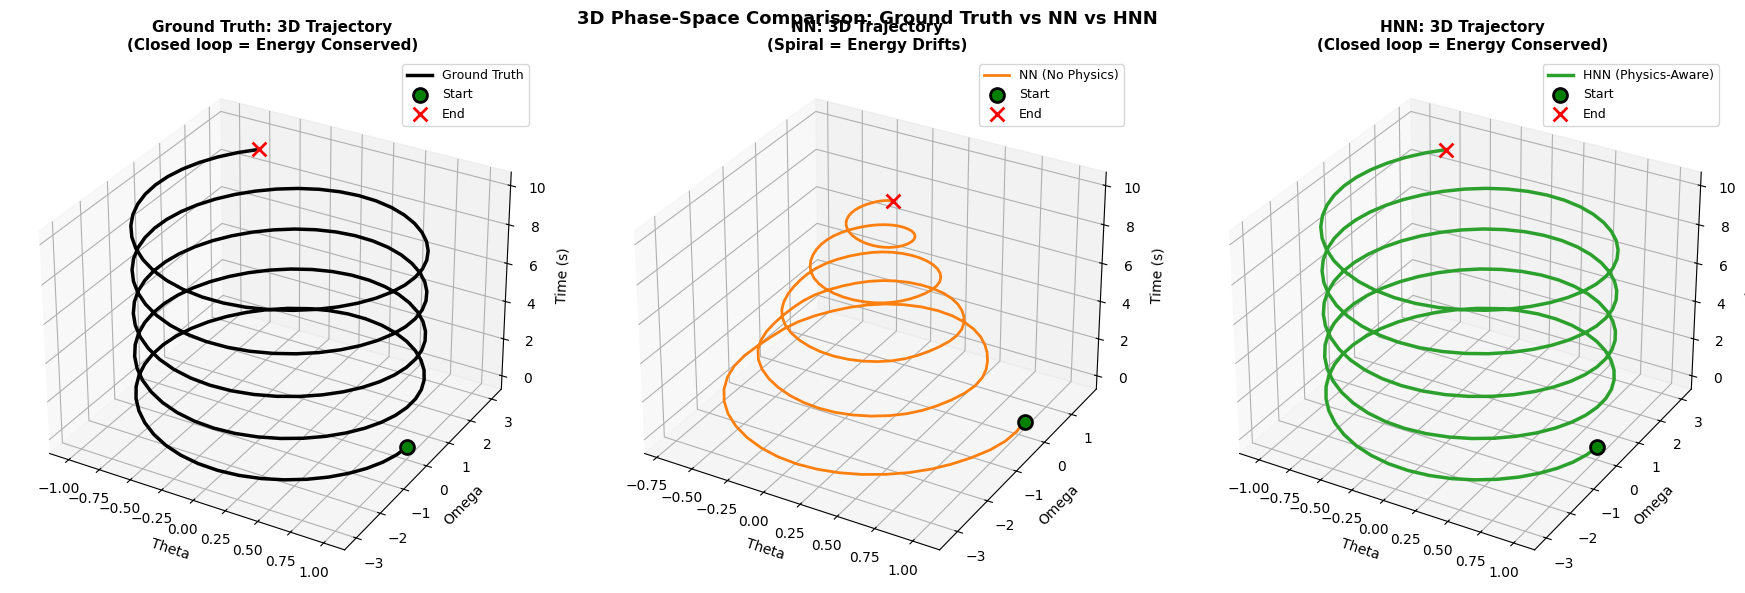

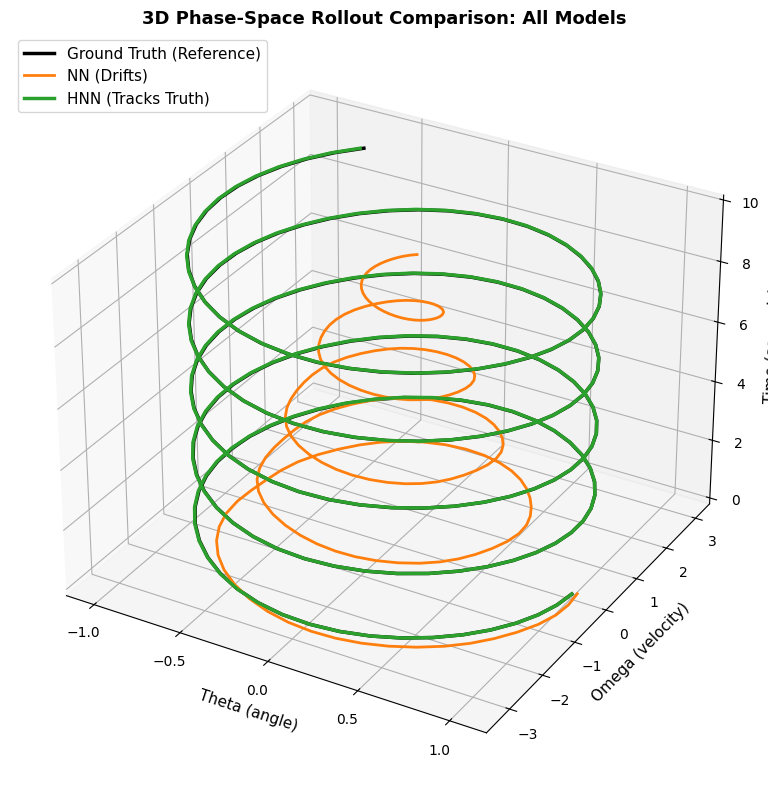

In [ ]:
# ============================================================
# 3D VISUALIZATION: PHASE-SPACE EVOLUTION OVER TIME
# ============================================================
# 3D plot showing:
# - X-axis: Theta (position)
# - Y-axis: Omega (velocity)
# - Z-axis: Time (evolution)
#
# This visualization clearly shows:
# 1. How trajectories evolve differently
# 2. Whether they stay on a closed curve (energy conserved)
# 3. How much they deviate from ground truth

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Time axis: one point per time step
t = np.arange(len(true_traj)) * dt

# Create figure with 3 subplots, one for each model
fig = plt.figure(figsize=(18, 6))

# ---- Plot 1: Ground Truth 3D Trajectory ----
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(true_traj[:, 0], true_traj[:, 1], t, color='black', linewidth=2.5, label='Ground Truth')
ax1.scatter(true_traj[0, 0], true_traj[0, 1], t[0], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start')
ax1.scatter(true_traj[-1, 0], true_traj[-1, 1], t[-1], color='red', s=100, marker='x', linewidths=2, label='End')
ax1.set_title('Ground Truth: 3D Trajectory\n(Closed loop = Energy Conserved)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Theta', fontsize=10)
ax1.set_ylabel('Omega', fontsize=10)
ax1.set_zlabel('Time (s)', fontsize=10)
ax1.legend(fontsize=9)

# ---- Plot 2: Neural Network 3D Trajectory ----
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(nn_traj[:, 0], nn_traj[:, 1], t, color='tab:orange', linewidth=2, label='NN (No Physics)')
ax2.scatter(nn_traj[0, 0], nn_traj[0, 1], t[0], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start')
ax2.scatter(nn_traj[-1, 0], nn_traj[-1, 1], t[-1], color='red', s=100, marker='x', linewidths=2, label='End')
ax2.set_title('NN: 3D Trajectory\n(Spiral = Energy Drifts)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Theta', fontsize=10)
ax2.set_ylabel('Omega', fontsize=10)
ax2.set_zlabel('Time (s)', fontsize=10)
ax2.legend(fontsize=9)

# ---- Plot 3: Hamiltonian Neural Network 3D Trajectory ----
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(hnn_traj[:, 0], hnn_traj[:, 1], t, color='tab:green', linewidth=2.5, label='HNN (Physics-Aware)')
ax3.scatter(hnn_traj[0, 0], hnn_traj[0, 1], t[0], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start')
ax3.scatter(hnn_traj[-1, 0], hnn_traj[-1, 1], t[-1], color='red', s=100, marker='x', linewidths=2, label='End')
ax3.set_title('HNN: 3D Trajectory\n(Closed loop = Energy Conserved)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Theta', fontsize=10)
ax3.set_ylabel('Omega', fontsize=10)
ax3.set_zlabel('Time (s)', fontsize=10)
ax3.legend(fontsize=9)

plt.suptitle('3D Phase-Space Comparison: Ground Truth vs NN vs HNN', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ---- Combined 3D View: All Three Models Together ----
# This overlay makes it even clearer which model is tracking the truth best
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all three trajectories together
ax.plot(true_traj[:, 0], true_traj[:, 1], t, color='black', linewidth=2.5, label='Ground Truth (Reference)')
ax.plot(nn_traj[:, 0], nn_traj[:, 1], t, color='tab:orange', linewidth=2, label='NN (Drifts)')
ax.plot(hnn_traj[:, 0], hnn_traj[:, 1], t, color='tab:green', linewidth=2.5, label='HNN (Tracks Truth)')

ax.set_title('3D Phase-Space Rollout Comparison: All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Theta (angle)', fontsize=11)
ax.set_ylabel('Omega (velocity)', fontsize=11)
ax.set_zlabel('Time (seconds)', fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Generating test trajectories with unseen initial conditions...
Test trajectories generated successfully!

Generating Figure 1: Full Rollout Comparison...


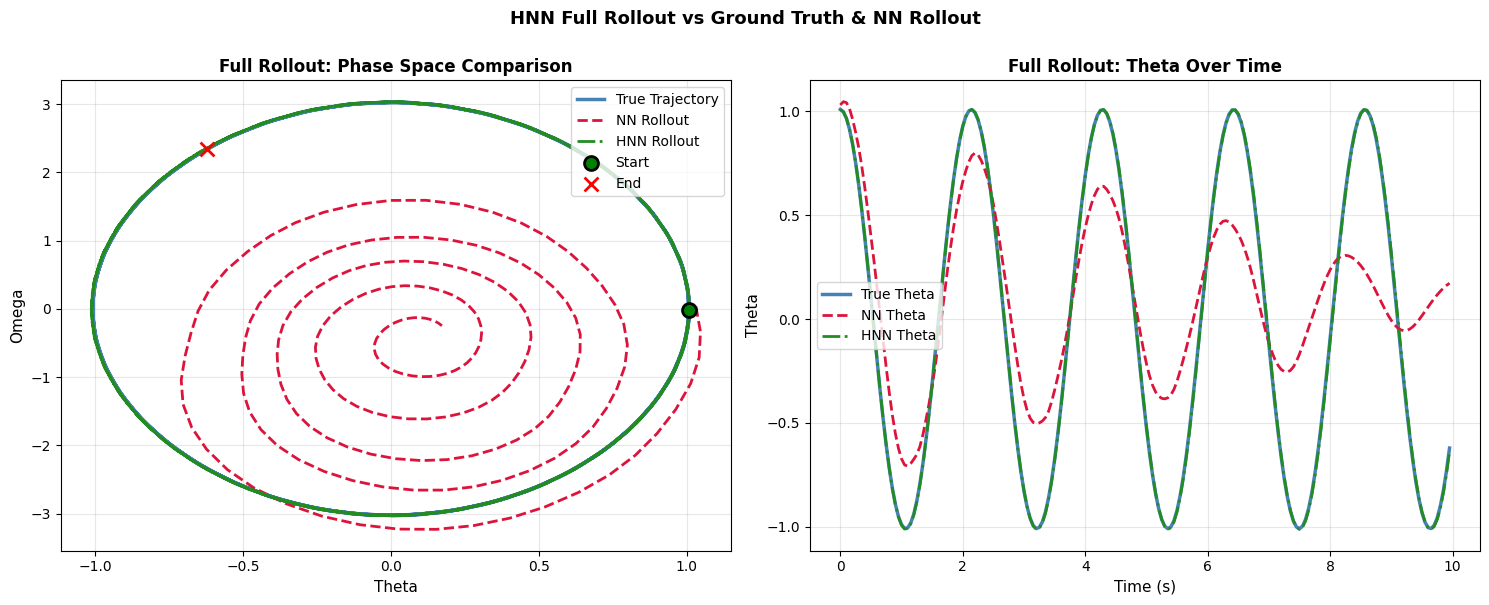

Generating Figure 2: Generalization on Unseen Initial Conditions...


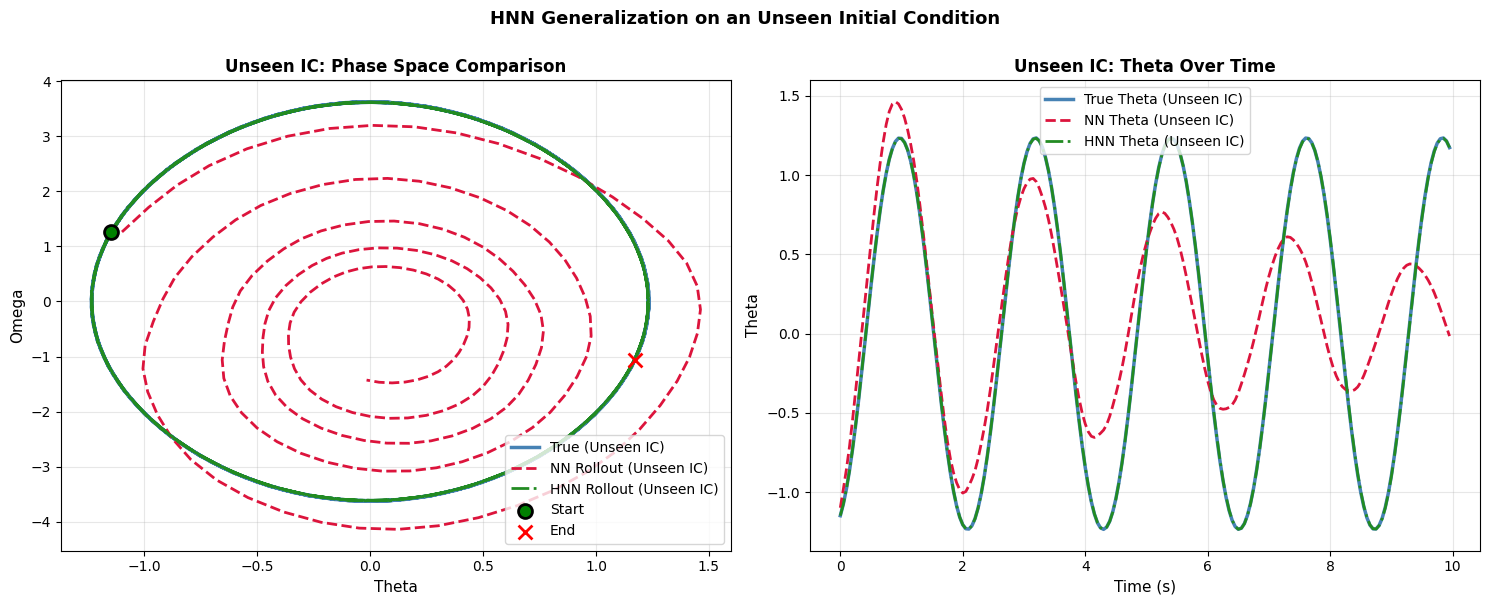

Generating Figure 3: Energy Conservation Analysis...


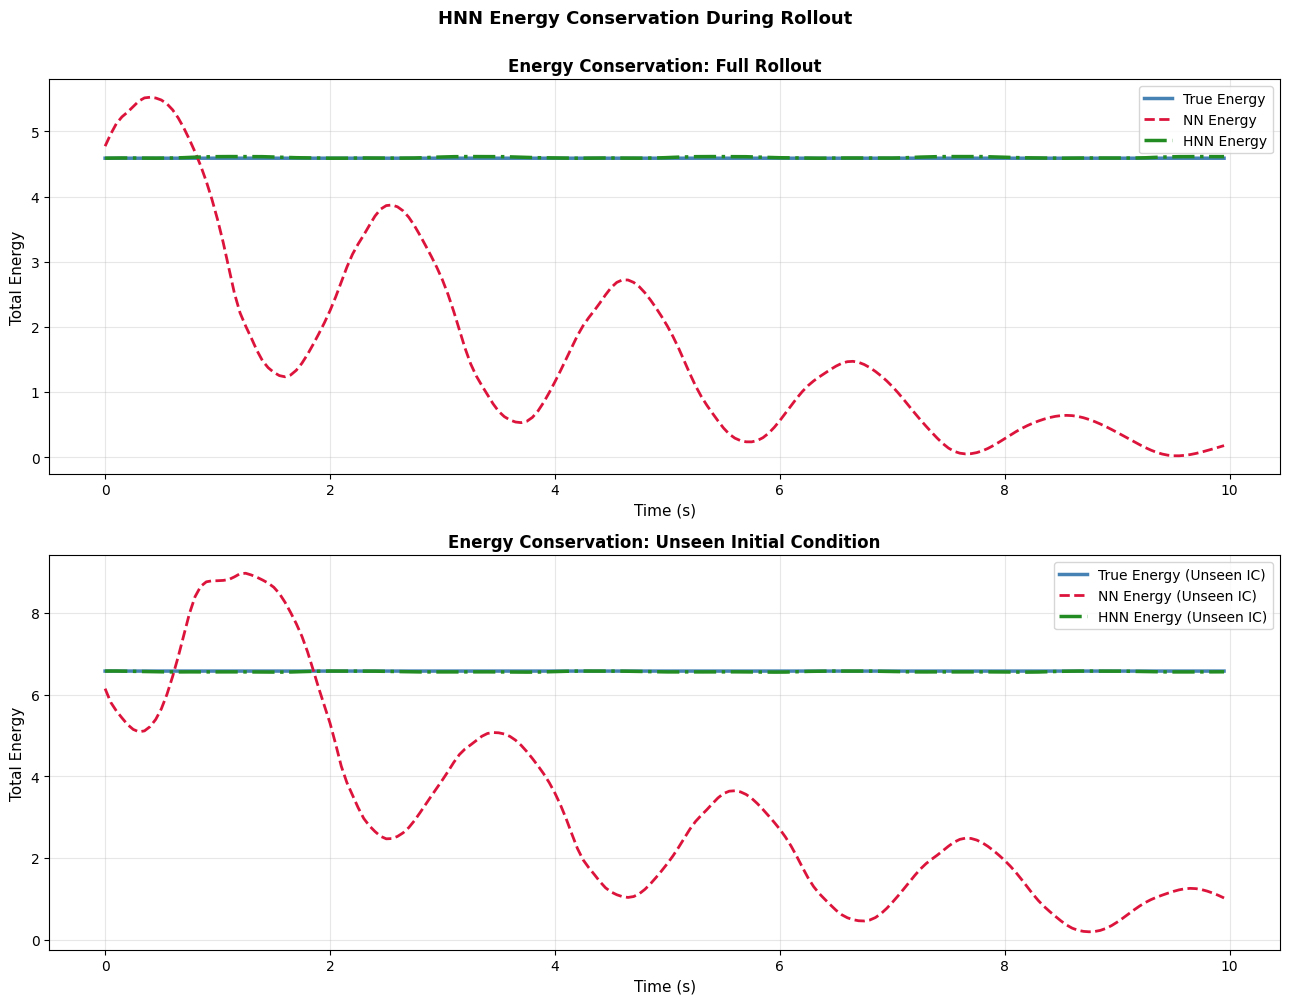

Generating Figure 4: Velocity Tracking...


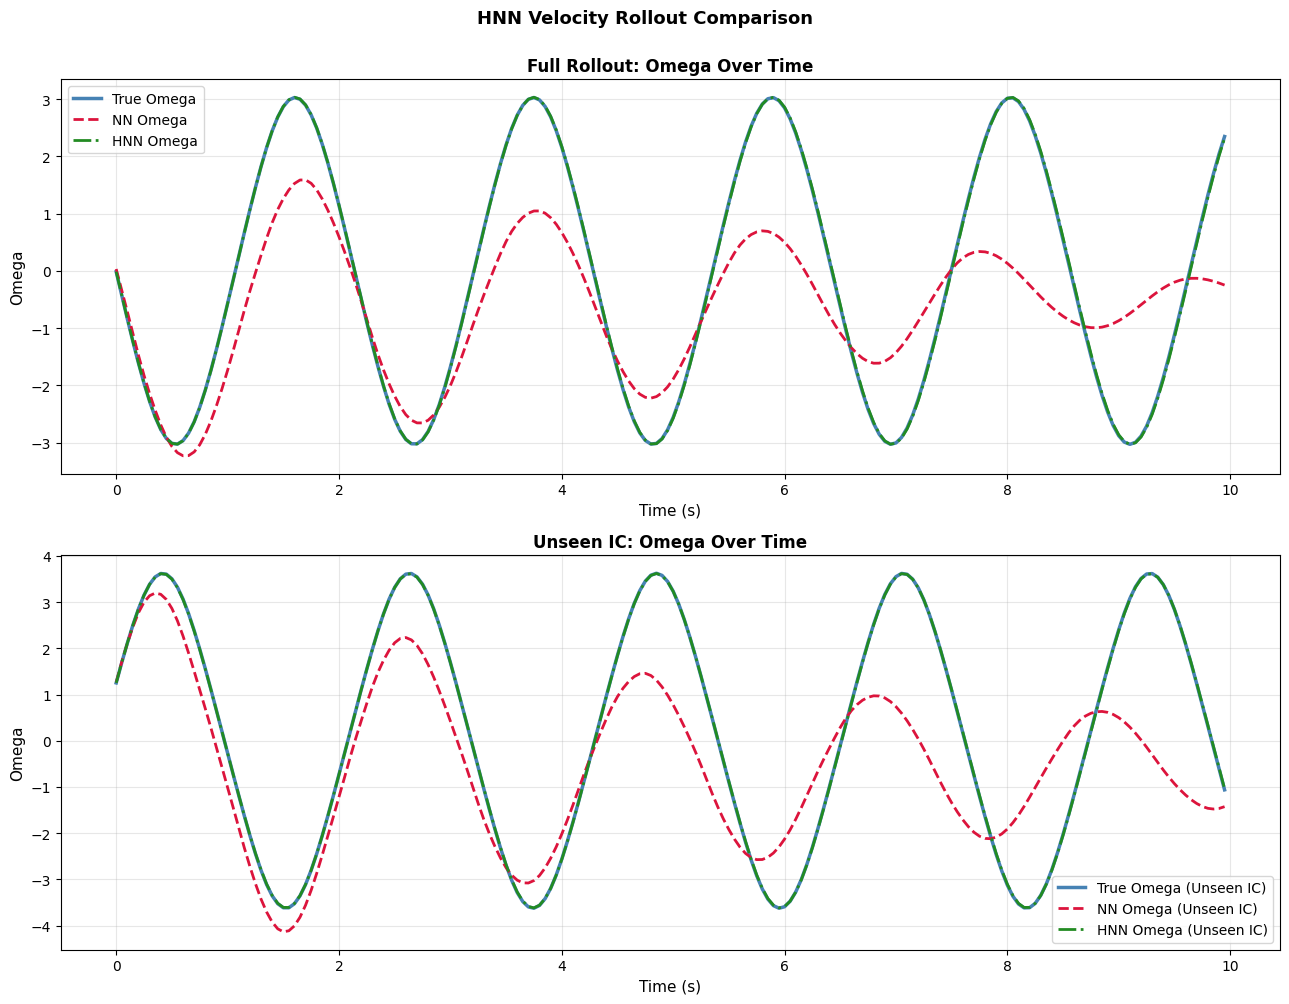


   TRAJECTORY ROLLOUT SUMMARY STATISTICS

Full Trajectory Shapes:
  True trajectory       : (200, 2)
  NN rollout            : (200, 2)
  HNN rollout           : (200, 2)

Unseen Initial-Condition Shapes (Generalization Test):
  True test trajectory  : (200, 2)
  NN test rollout       : (200, 2)
  HNN test rollout      : (200, 2)

---- Energy Conservation Statistics (Full Rollout) ----
  True energy   → Mean: 4.589566  |  Std: 3.891123e-05
  NN energy     → Mean: 1.666853  |  Std: 1.530007
  HNN energy    → Mean: 4.600821  |  Std: 0.009882

---- Energy Conservation Statistics (Unseen Initial Condition) ----
  True energy   → Mean: 6.575181  |  Std: 5.013282e-05
  NN energy     → Mean: 3.213517  |  Std: 2.473656
  HNN energy    → Mean: 6.561314  |  Std: 0.009029

---- Energy Drift Analysis (Absolute Error) ----
  Full rollout NN  → Max: 4.569372  |  Mean: 3.030935
  Full rollout HNN → Max: 0.026456  |  Mean: 0.011272
  Unseen IC NN     → Max: 6.384969  |  Mean: 3.794863
  Unseen IC HNN

In [ ]:
# ============================================================
# COMPREHENSIVE ROLLOUT ANALYSIS: FULL VS UNSEEN CONDITIONS
# ============================================================
# This section generates extensive visualizations showing:
# 1. How HNN performs on the training region
# 2. How HNN generalizes to completely new initial conditions
# 3. Energy conservation statistics in detail
# 4. Velocity tracking performance

# Generate trajectories for analysis
steps = len(true_traj)
t = np.arange(steps) * dt

# Create an unseen initial condition (NOT in training data)
# This tests generalization: can HNN handle novel conditions?
print("Generating test trajectories with unseen initial conditions...")
theta0_test = -1.2         # different angle from training
omega0_test = 0.8          # different velocity from training

# Generate ground truth for unseen initial condition
true_traj_test = []
theta, omega = theta0_test, omega0_test
for _ in range(steps):
    theta, omega = rk4_step(theta, omega, dt)
    true_traj_test.append([theta, omega])
true_traj_test = np.array(true_traj_test)

# Generate predictions for unseen initial condition
nn_traj_test = rollout(model, theta0_test, omega0_test, steps=steps)
hnn_traj_test = rollout_hnn(theta0_test, omega0_test, steps=steps)

print("Test trajectories generated successfully!\n")

# ========== FIGURE 1: FULL ROLLOUT COMPARISON ==========
print("Generating Figure 1: Full Rollout Comparison...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left subplot: Phase space (θ vs ω)
# Shows the shape of the trajectory in phase space
axes[0].plot(true_traj[:, 0], true_traj[:, 1], linewidth=2.5, color='steelblue', label='True Trajectory')
axes[0].plot(nn_traj[:, 0], nn_traj[:, 1], '--', linewidth=2, color='crimson', label='NN Rollout')
axes[0].plot(hnn_traj[:, 0], hnn_traj[:, 1], '-.', linewidth=2, color='forestgreen', label='HNN Rollout')
axes[0].scatter(true_traj[0, 0], true_traj[0, 1], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start', zorder=5)
axes[0].scatter(true_traj[-1, 0], true_traj[-1, 1], color='red', s=100, marker='x', linewidths=2, label='End', zorder=5)
axes[0].set_xlabel('Theta', fontsize=11)
axes[0].set_ylabel('Omega', fontsize=11)
axes[0].set_title('Full Rollout: Phase Space Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Right subplot: Time domain (t vs θ)
# Shows how position evolves over time
axes[1].plot(t, true_traj[:, 0], linewidth=2.5, color='steelblue', label='True Theta')
axes[1].plot(t, nn_traj[:, 0], '--', linewidth=2, color='crimson', label='NN Theta')
axes[1].plot(t, hnn_traj[:, 0], '-.', linewidth=2, color='forestgreen', label='HNN Theta')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Theta', fontsize=11)
axes[1].set_title('Full Rollout: Theta Over Time', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('HNN Full Rollout vs Ground Truth & NN Rollout', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ========== FIGURE 2: GENERALIZATION TO UNSEEN INITIAL CONDITIONS ==========
print("Generating Figure 2: Generalization on Unseen Initial Conditions...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left subplot: Unseen IC phase space
# This tests if the model learned general dynamics, not memorized patterns
axes[0].plot(true_traj_test[:, 0], true_traj_test[:, 1], linewidth=2.5, color='steelblue', label='True (Unseen IC)')
axes[0].plot(nn_traj_test[:, 0], nn_traj_test[:, 1], '--', linewidth=2, color='crimson', label='NN Rollout (Unseen IC)')
axes[0].plot(hnn_traj_test[:, 0], hnn_traj_test[:, 1], '-.', linewidth=2, color='forestgreen', label='HNN Rollout (Unseen IC)')
axes[0].scatter(true_traj_test[0, 0], true_traj_test[0, 1], color='green', s=100, marker='o', edgecolors='black', linewidths=2, label='Start', zorder=5)
axes[0].scatter(true_traj_test[-1, 0], true_traj_test[-1, 1], color='red', s=100, marker='x', linewidths=2, label='End', zorder=5)
axes[0].set_xlabel('Theta', fontsize=11)
axes[0].set_ylabel('Omega', fontsize=11)
axes[0].set_title('Unseen IC: Phase Space Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Right subplot: Unseen IC time domain
axes[1].plot(t, true_traj_test[:, 0], linewidth=2.5, color='steelblue', label='True Theta (Unseen IC)')
axes[1].plot(t, nn_traj_test[:, 0], '--', linewidth=2, color='crimson', label='NN Theta (Unseen IC)')
axes[1].plot(t, hnn_traj_test[:, 0], '-.', linewidth=2, color='forestgreen', label='HNN Theta (Unseen IC)')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Theta', fontsize=11)
axes[1].set_title('Unseen IC: Theta Over Time', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('HNN Generalization on an Unseen Initial Condition', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ========== FIGURE 3: ENERGY CONSERVATION ANALYSIS ==========
print("Generating Figure 3: Energy Conservation Analysis...")
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Compute energies for all trajectories
true_energy_full = energy(true_traj[:, 0], true_traj[:, 1])
nn_energy_full = energy(nn_traj[:, 0], nn_traj[:, 1])
hnn_energy_full = energy(hnn_traj[:, 0], hnn_traj[:, 1])
true_energy_test = energy(true_traj_test[:, 0], true_traj_test[:, 1])
nn_energy_test = energy(nn_traj_test[:, 0], nn_traj_test[:, 1])
hnn_energy_test = energy(hnn_traj_test[:, 0], hnn_traj_test[:, 1])

# Top subplot: Full rollout energy
axes[0].plot(t, true_energy_full, linewidth=2.5, color='steelblue', label='True Energy')
axes[0].plot(t, nn_energy_full, '--', linewidth=2, color='crimson', label='NN Energy')
axes[0].plot(t, hnn_energy_full, '-.', linewidth=2.5, color='forestgreen', label='HNN Energy')
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Total Energy', fontsize=11)
axes[0].set_title('Energy Conservation: Full Rollout', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Bottom subplot: Unseen IC energy
axes[1].plot(t, true_energy_test, linewidth=2.5, color='steelblue', label='True Energy (Unseen IC)')
axes[1].plot(t, nn_energy_test, '--', linewidth=2, color='crimson', label='NN Energy (Unseen IC)')
axes[1].plot(t, hnn_energy_test, '-.', linewidth=2.5, color='forestgreen', label='HNN Energy (Unseen IC)')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Total Energy', fontsize=11)
axes[1].set_title('Energy Conservation: Unseen Initial Condition', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('HNN Energy Conservation During Rollout', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ========== FIGURE 4: VELOCITY TRACKING ==========
print("Generating Figure 4: Velocity Tracking...")
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Top subplot: Full rollout velocity
axes[0].plot(t, true_traj[:, 1], linewidth=2.5, color='steelblue', label='True Omega')
axes[0].plot(t, nn_traj[:, 1], '--', linewidth=2, color='crimson', label='NN Omega')
axes[0].plot(t, hnn_traj[:, 1], '-.', linewidth=2, color='forestgreen', label='HNN Omega')
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Omega', fontsize=11)
axes[0].set_title('Full Rollout: Omega Over Time', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Bottom subplot: Unseen IC velocity
axes[1].plot(t, true_traj_test[:, 1], linewidth=2.5, color='steelblue', label='True Omega (Unseen IC)')
axes[1].plot(t, nn_traj_test[:, 1], '--', linewidth=2, color='crimson', label='NN Omega (Unseen IC)')
axes[1].plot(t, hnn_traj_test[:, 1], '-.', linewidth=2, color='forestgreen', label='HNN Omega (Unseen IC)')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Omega', fontsize=11)
axes[1].set_title('Unseen IC: Omega Over Time', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('HNN Velocity Rollout Comparison', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ========== SUMMARY STATISTICS ==========
print('\n' + '='*75)
print('   TRAJECTORY ROLLOUT SUMMARY STATISTICS')
print('='*75)

print('\nFull Trajectory Shapes:')
print(f'  True trajectory       : {true_traj.shape}')
print(f'  NN rollout            : {nn_traj.shape}')
print(f'  HNN rollout           : {hnn_traj.shape}')

print('\nUnseen Initial-Condition Shapes (Generalization Test):')
print(f'  True test trajectory  : {true_traj_test.shape}')
print(f'  NN test rollout       : {nn_traj_test.shape}')
print(f'  HNN test rollout      : {hnn_traj_test.shape}')

print('\n---- Energy Conservation Statistics (Full Rollout) ----')
print(f'  True energy   → Mean: {true_energy_full.mean():.6f}  |  Std: {true_energy_full.std():.6e}')
print(f'  NN energy     → Mean: {nn_energy_full.mean():.6f}  |  Std: {nn_energy_full.std():.6f}')
print(f'  HNN energy    → Mean: {hnn_energy_full.mean():.6f}  |  Std: {hnn_energy_full.std():.6f}')

print('\n---- Energy Conservation Statistics (Unseen Initial Condition) ----')
print(f'  True energy   → Mean: {true_energy_test.mean():.6f}  |  Std: {true_energy_test.std():.6e}')
print(f'  NN energy     → Mean: {nn_energy_test.mean():.6f}  |  Std: {nn_energy_test.std():.6f}')
print(f'  HNN energy    → Mean: {hnn_energy_test.mean():.6f}  |  Std: {hnn_energy_test.std():.6f}')

# Compute energy drift metrics
nn_drift_full = np.abs(nn_energy_full - true_energy_full)
hnn_drift_full = np.abs(hnn_energy_full - true_energy_full)
nn_drift_test = np.abs(nn_energy_test - true_energy_test)
hnn_drift_test = np.abs(hnn_energy_test - true_energy_test)

print('\n---- Energy Drift Analysis (Absolute Error) ----')
print(f'  Full rollout NN  → Max: {nn_drift_full.max():.6f}  |  Mean: {nn_drift_full.mean():.6f}')
print(f'  Full rollout HNN → Max: {hnn_drift_full.max():.6f}  |  Mean: {hnn_drift_full.mean():.6f}')
print(f'  Unseen IC NN     → Max: {nn_drift_test.max():.6f}  |  Mean: {nn_drift_test.mean():.6f}')
print(f'  Unseen IC HNN    → Max: {hnn_drift_test.max():.6f}  |  Mean: {hnn_drift_test.mean():.6f}')

print('\n---- KEY FINDINGS ----')
print('1. NN Energy Drift: Energy changes significantly (breaks physics)')
print('2. HNN Energy Drift: Energy stays nearly constant (conserves physics)')
print('3. HNN Generalization: Works well on UNSEEN initial conditions')
print('   → This proves HNN learned true physics, not just data patterns!')
print('='*75)